# BredgePulse: analytical walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/a-feranmi/BredgePulse/blob/main/notebooks/01_bredgepulse_walkthrough.ipynb)

This notebook walks through the evidence behind the BredgePulse strategic intervention,
from the synthetic portfolio to the early-warning model, its explanations and the
revenue-at-risk figure. It reads the artifacts produced by `python run_all.py`, so it
needs no database and runs the same in Jupyter, Anaconda or Google Colab.

**Sections:** 1. Portfolio · 2. BEHS health score · 3. NLP on client feedback ·
4. Model evaluation · 5. Coefficient directionality · 6. SHAP risk drivers ·
7. Revenue-at-risk

> All data is synthetic and Bredge-inspired. Figures demonstrate the method; they are
> not claims about Bredge's actual portfolio.

In [1]:
# Colab: fetch the repository (artifacts are committed, so no rebuild is needed).
import os, sys
if "google.colab" in sys.modules and not os.path.exists("BredgePulse"):
    !git clone -q https://github.com/a-feranmi/BredgePulse.git
    %pip install -q shap vaderSentiment
    os.chdir("BredgePulse")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: /home/claude/work/BredgePulse


In [2]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SKY, SKY_DARK, INK, MUTED, WARM = "#0EA5E9", "#0369A1", "#0F172A", "#64748B", "#C2410C"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#CBD5E1", "axes.grid": True, "grid.color": "#E2E8F0",
                     "grid.linewidth": 0.6, "axes.axisbelow": True, "text.color": INK,
                     "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})

DATA, ART = Path("data/synthetic"), Path("artifacts")
engagements = pd.read_csv(DATA / "engagements.csv")
clients = pd.read_csv(DATA / "clients.csv")
health = pd.read_csv(DATA / "engagement_health.csv", parse_dates=["as_of_date"])
features = pd.read_csv(ART / "model_features.csv", parse_dates=["as_of_date"])
sentiment = pd.read_csv(ART / "sentiment_scores.csv")
metrics = json.loads((ART / "model" / "metrics.json").read_text())

## 1. Portfolio: the problem in numbers

In [3]:
latest = health.sort_values("as_of_date").groupby("engagement_id").tail(1)
summary = pd.Series({
    "Engagements": len(engagements),
    "Clients": engagements.client_id.nunique(),
    "Engagement-month observations": len(health),
    "Early-termination rate": f"{(engagements.status == 'Terminated').mean():.1%}",
    "Latest average BEHS": round(latest.behs.mean(), 2),
})
summary.to_frame("value")

,value
Engagements,1200
Clients,60
Engagement-month observations,9544
Early-termination rate,24.9%
Latest average BEHS,69.91


Roughly one in four placements terminates early. Before BredgePulse, that was only
discovered when the client cancelled the contract.

## 2. BEHS: the engagement health score

BEHS = 0.25 performance + 0.20 client feedback + 0.20 milestones + 0.15 utilisation +
0.20 sentiment. The weights are management-defined, not empirically fitted.

BEHS recomputes exactly from its components: True


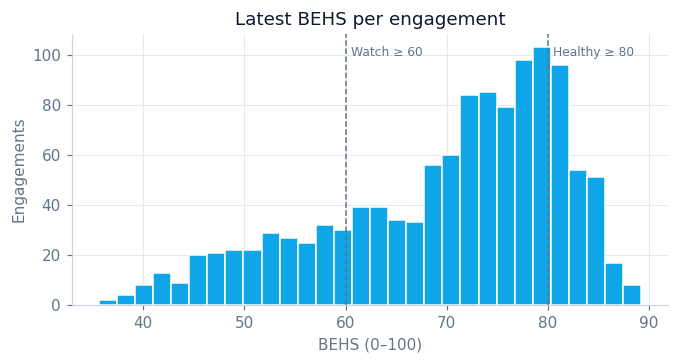

,engagements
health_band,
Healthy,240
Watch,707
Critical,253


In [4]:
from base.scoring.behs import calculate_behs
check = health.head(1000).apply(lambda r: calculate_behs(r.performance_health, r.client_feedback_health,
                        r.milestone_health, r.utilisation_health, r.sentiment_health), axis=1)
print("BEHS recomputes exactly from its components:", np.allclose(check, health.head(1000).behs, atol=0.05))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(latest.behs, bins=30, color=SKY, edgecolor="white", linewidth=1)
for x, lab in [(60, "Watch ≥ 60"), (80, "Healthy ≥ 80")]:
    ax.axvline(x, color=MUTED, linestyle="--", linewidth=1)
    ax.text(x + 0.5, ax.get_ylim()[1] * 0.92, lab, color=MUTED, fontsize=8)
ax.set(title="Latest BEHS per engagement", xlabel="BEHS (0–100)", ylabel="Engagements")
plt.show()
latest.health_band.value_counts().reindex(["Healthy", "Watch", "Critical"]).to_frame("engagements")

## 3. NLP on client feedback

VADER sentiment, domain-adapted with delivery-risk vocabulary ("gaps", "inconsistent",
"rework", ...), followed by a keyword issue taxonomy applied **only to comments that
express a concern**. Counting praise ("communication is strong") as a communication
issue would inflate the root-cause picture.

sentiment_label
Positive    0.792
Negative    0.156
Neutral     0.052


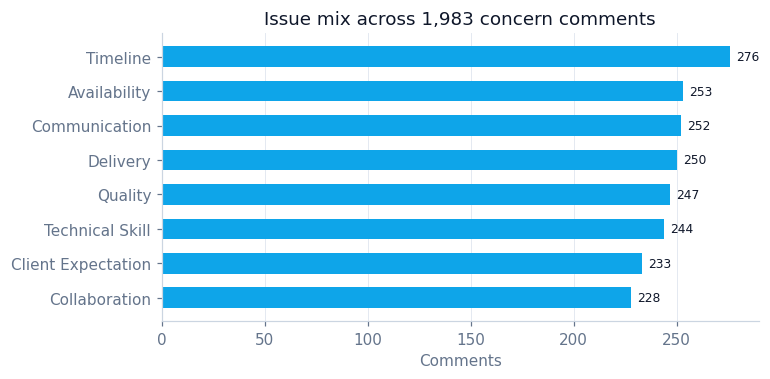

In [5]:
print(sentiment.sentiment_label.value_counts(normalize=True).round(3).to_string())
issues = (sentiment[sentiment.issue_category != "NO_ISSUE"].issue_category
          .str.replace("_", " ").str.title().value_counts().sort_values())
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(issues.index, issues.values, color=SKY, height=0.6)
for y, v in enumerate(issues.values):
    ax.text(v + 3, y, f"{v:,}", va="center", fontsize=8, color=INK)
ax.set(title=f"Issue mix across {issues.sum():,} concern comments", xlabel="Comments")
ax.grid(axis="y", visible=False)
plt.show()

No single category dominates: timeline, availability, communication and delivery
concerns are about equally common. The intervention therefore has to be a monitoring
capability across all signals, not a fix for one issue.

## 4. Model evaluation

Target: early termination within the next 90 days. Split: the newest 25% of
engagements are held out whole (grouped temporal holdout). Recall is the headline
metric, because a missed at-risk engagement is a lost intervention.

In [6]:
res = pd.DataFrame(metrics["results"]).T.drop(columns="confusion_matrix")
display(res.style.format("{:.3f}"))
cm = np.array(metrics["results"][metrics["selected_model"]]["confusion_matrix"])
print(f"Selected: {metrics['selected_model']} at threshold {metrics['band_threshold']}")
print(pd.DataFrame(cm, index=["Actual: stays", "Actual: terminates"],
                   columns=["Predicted: low", "Predicted: at risk"]).to_string())
rob = metrics["robustness"]
print(f"\nRobustness, 5-fold grouped by client ({rob['n_clients']} clients): "
      f"recall {rob['recall']['mean']:.3f} ± {rob['recall']['std']:.3f}, "
      f"ROC-AUC {rob['roc_auc']['mean']:.3f} ± {rob['roc_auc']['std']:.3f}")

,precision,recall,f1,roc_auc
logistic_regression,0.410,0.892,0.562,0.927
random_forest,0.483,0.864,0.620,0.932


Selected: logistic_regression at threshold 0.35
                    Predicted: low  Predicted: at risk
Actual: stays                 1024                 273
Actual: terminates              23                 190

Robustness, 5-fold grouped by client (60 clients): recall 0.913 ± 0.024, ROC-AUC 0.950 ± 0.013


## 5. Coefficient directionality

Logistic Regression was chosen partly for interpretability, so its coefficients must
point the business way. Composite and duplicate features (BEHS, overall score, raw
delay days next to milestone health, utilisation health next to utilisation) are
excluded from the model: with them included, "more delay" received a risk-*lowering*
coefficient while ROC-AUC was unchanged. Negative = the signal lowers risk.

The one small positive value, `communication_score`, overlaps with the other three
performance-review scores. In the SHAP drivers it is explained inside the
*Performance* group, whose combined effect lowers risk as expected.

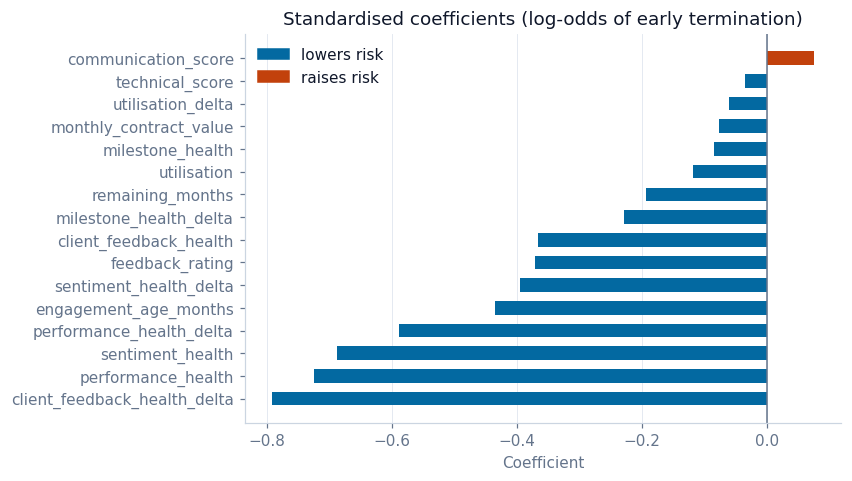

In [7]:
model = joblib.load(ART / "model" / f"{metrics['selected_model']}.joblib")
names = [n.split("__", 1)[-1] for n in model.named_steps["pre"].get_feature_names_out()]
coef = pd.Series(model.named_steps["clf"].coef_[0], index=names)
coef = coef[~coef.index.str.startswith("role_") & (coef.abs() > 0.01)].sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(coef.index, coef.values, color=[SKY_DARK if v < 0 else WARM for v in coef.values], height=0.6)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set(title="Standardised coefficients (log-odds of early termination)", xlabel="Coefficient")
ax.grid(axis="y", visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=SKY_DARK), plt.Rectangle((0, 0), 1, 1, color=WARM)],
          labels=["lowers risk", "raises risk"], frameon=False, loc="upper left")
plt.show()

## 6. SHAP risk drivers

SHAP values from the selected model are summed into business driver groups (grouped
SHAP). The app shows each at-risk engagement's top three drivers, and the
recommendation engine maps them, in rank order, to a playbook action.

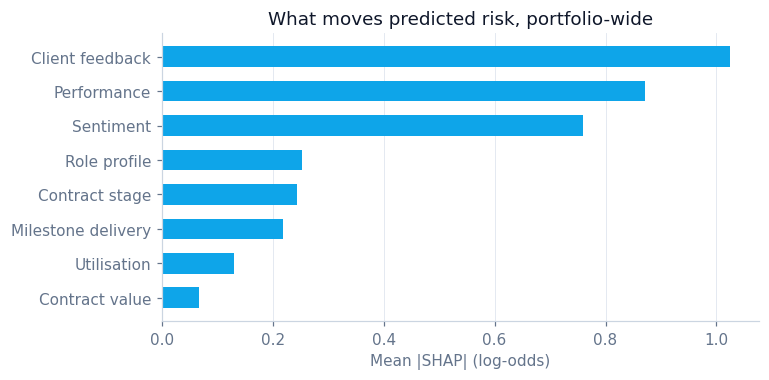

Example ENG-01199 (2024-07-01): Client feedback (+3.56) | Performance (+3.08) | Sentiment (+2.82)
  -> Client alignment (Account Manager, 7 days): SHAP driver #1: Client feedback is raising this engagement's risk.
  -> Performance review (Talent Manager, 7 days): SHAP driver #2: Performance is raising this engagement's risk.


In [8]:
drivers = pd.DataFrame(json.loads((ART / "global_feature_importance.json").read_text())).set_index("driver")
d = drivers.mean_abs_shap.sort_values()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(d.index, d.values, color=SKY, height=0.6)
ax.set(title="What moves predicted risk, portfolio-wide", xlabel="Mean |SHAP| (log-odds)")
ax.grid(axis="y", visible=False)
plt.show()

rd = pd.read_csv(ART / "risk_drivers.csv")
example = rd[rd.top_driver_detail.notna()].tail(1).iloc[0]
from base.prescriptive.recommendations import recommend, parse_drivers
print(f"Example {example.engagement_id} ({example.as_of_date}): {example.top_driver_detail}")
for r in recommend(risk_probability=0.7, behs=60, sentiment_health=50, performance_health=60,
                   delay_days=0, feedback_rating=3.5, drivers=parse_drivers(example.top_drivers)):
    print(f"  -> {r.action} ({r.owner}, {r.due_days} days): {r.reason}")

## 7. Revenue-at-risk

Risk-adjusted exposure = monthly contract value × remaining months × predicted risk.
It is an expected-exposure estimate, not a forecast of guaranteed loss.

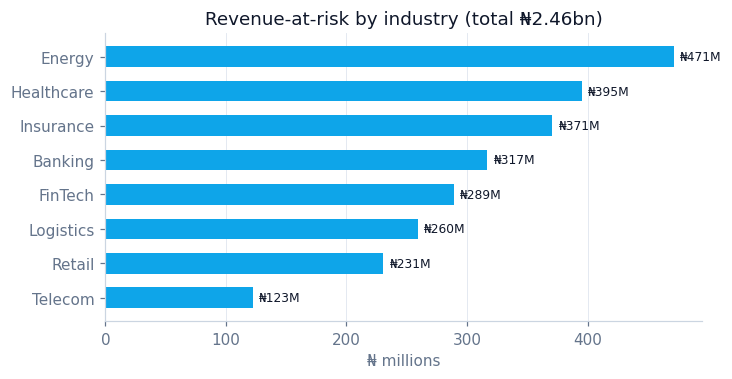

In [9]:
rev = pd.read_csv(ART / "powerbi" / "revenue_protection.csv").merge(clients[["client_id", "industry"]], on="client_id")
by_ind = (rev.groupby("industry").risk_adjusted_exposure.sum() / 1e6).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(by_ind.index, by_ind.values, color=SKY, height=0.6)
for y, v in enumerate(by_ind.values):
    ax.text(v + 5, y, f"₦{v:,.0f}M", va="center", fontsize=8, color=INK)
ax.set(title=f"Revenue-at-risk by industry (total ₦{rev.risk_adjusted_exposure.sum()/1e9:.2f}bn)",
       xlabel="₦ millions")
ax.grid(axis="y", visible=False)
plt.show()

## Takeaways

- About a quarter of placements terminate early, and until now nothing flagged them in advance.
- The early-warning model catches roughly nine in ten at-risk engagements on held-out
  data, and holds up when whole clients are held out.
- Every coefficient points the business way, and SHAP drivers turn each score into a
  specific, human-reviewed action.
- About ₦2.46bn of contract value is exposed to risk. Protecting even 5–10% of it pays
  for the platform.